In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

def p_to_star(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

In [2]:
adata_sigma = sc.read_h5ad("/mnt/projects_tn03/Data_MK/article/results_dominguez/merge.h5ad")
adata_author = sc.read_h5ad("/home/lemgui01/raw_STUDIES_thesis/healthy/Dominguez_science_science-abl5197.h5ad")

adata_author.X = adata_author.layers["counts"]

adata_sigma.obs_names = adata_sigma.obs_names.str.replace(
    r"-Dominguez_.*?_data$",
    "",
    regex=True
)

In [12]:
adata_sigma.n_obs

41214

In [3]:
adata_sumry = ad.AnnData(adata_author.X)
adata_sumry.obs_names = adata_author.obs_names

# Add var table
adata_sumry.var_names = adata_author.var_names

# Add UMAP coordinates
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]

# Add counts table
adata_sumry.layers["raw"] = adata_author.layers["counts"]
adata_sumry.layers["log1p"] = adata_author.X

# Add obs table
adata_sumry.obs_names = adata_author.obs_names
adata_sumry.obs["donor"] = adata_author.obs["Donor"]
adata_sumry.obs["sex"] = adata_author.obs["Sex"]
adata_sumry.obs["age"] = adata_author.obs["Age_range"]
adata_sumry.obs["organ"] = adata_author.obs["Organ"]
adata_sumry.obs["assay"] = adata_author.obs["Chemistry"]
adata_sumry.obs["celltype"] = adata_author.obs["Predicted_labels_CellTypist"]

adata_sumry.obs["score"] = 0.0
common_idx = adata_sigma.obs_names.intersection(adata_sumry.obs_names)
adata_sumry.obs.loc[common_idx, "score"] = adata_sigma.obs.loc[common_idx, "score"].values

proba_cols = [col for col in adata_sigma.obs.columns if col.startswith("proba_")]
for prob in proba_cols:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)
adata_sumry

AnnData object with n_obs × n_vars = 329762 × 36601
    obs: 'donor', 'sex', 'age', 'organ', 'assay', 'celltype', 'score', 'proba_target', 'proba_LowIn'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'raw', 'log1p'

# Score plot

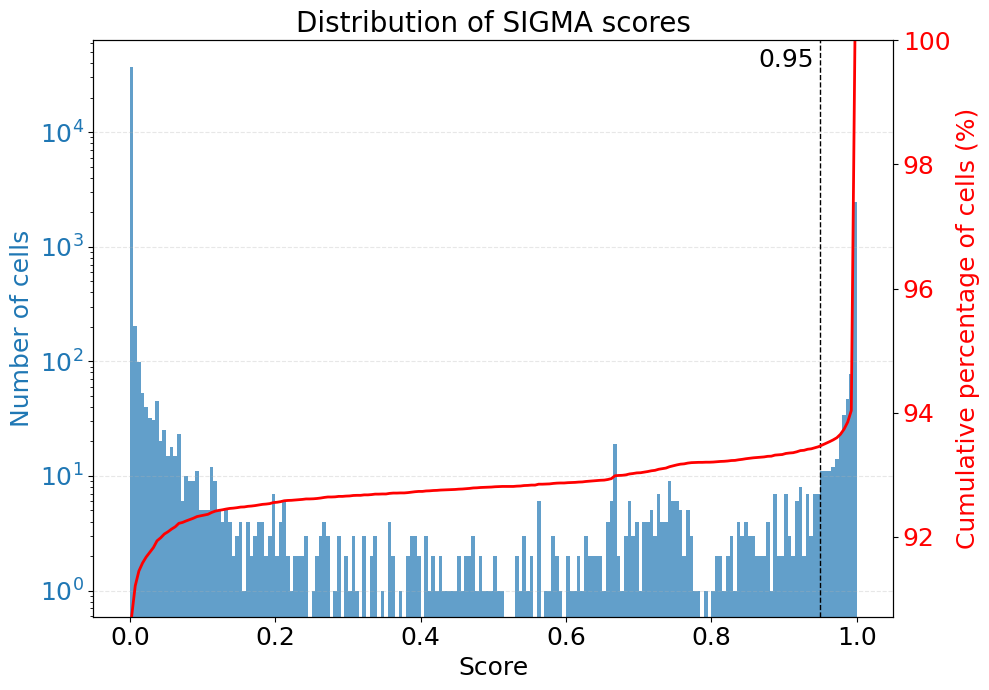

In [4]:
seuil = 0.95

fig, ax1 = plt.subplots(figsize=(10,7))

# Histogramme
n, bins, patches = ax1.hist(adata_sigma.obs["score"], bins=200, alpha=0.7, label='Count')
ax1.set_xlabel("Score")
ax1.set_ylabel("Number of cells", color='C0')
ax1.set_yscale("log")
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Somme cumulée sur un second axe
ax2 = ax1.twinx()
cumsum_pct = 100 * np.cumsum(n) / np.sum(n)
bin_centers = (bins[:-1] + bins[1:]) / 2
ax2.plot(bin_centers, cumsum_pct, color='red', linewidth=2, label='Cumulative %')
ax2.set_ylabel("Cumulative percentage of cells (%)", color='red')
ax2.set_ylim(min(cumsum_pct), 100)
ax2.tick_params(axis='y', labelcolor='red')

# Ligne verticale pour le seuil
ax1.axvline(seuil, color='black', linestyle='--', linewidth=1)
ax1.text(seuil-0.085, ax1.get_ylim()[1]*0.85, str(seuil), color='black', ha='left', va='top', fontsize=18)
ax1.set_title("Distribution of SIGMA scores")

ax1.tick_params(axis="both", labelsize=18)
ax2.tick_params(axis="y", labelsize=18)
ax1.xaxis.label.set_size(18)
ax1.yaxis.label.set_size(18)
ax2.yaxis.label.set_size(18)
ax1.title.set_size(20)

fig.tight_layout()
fig.savefig("figures/dominguez_Score_cumulative.svg", bbox_inches="tight", dpi=500)
plt.show()

In [ ]:
tem_found_by_sigma = adata_sumry.obs["score"] >= seuil
adata_sumry.obs["Identified by SIGMA"] = tem_found_by_sigma.astype(str)
adata_sumry.obs["Identified by SIGMA"] = pd.Categorical(adata_sumry.obs["Identified by SIGMA"],
                                                        categories=["False", "True"], ordered=True)

print(f"# Tem cyto : {np.sum(tem_found_by_sigma)}")
print(f"% among all cells : {np.sum(tem_found_by_sigma)/adata_sumry.n_obs*100:.3%}")

sub_adata_sumry = adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "True"]

# Tem cyto : 2698
% among all cells : 0.818 %


/tmp/ipykernel_2123873/545434448.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


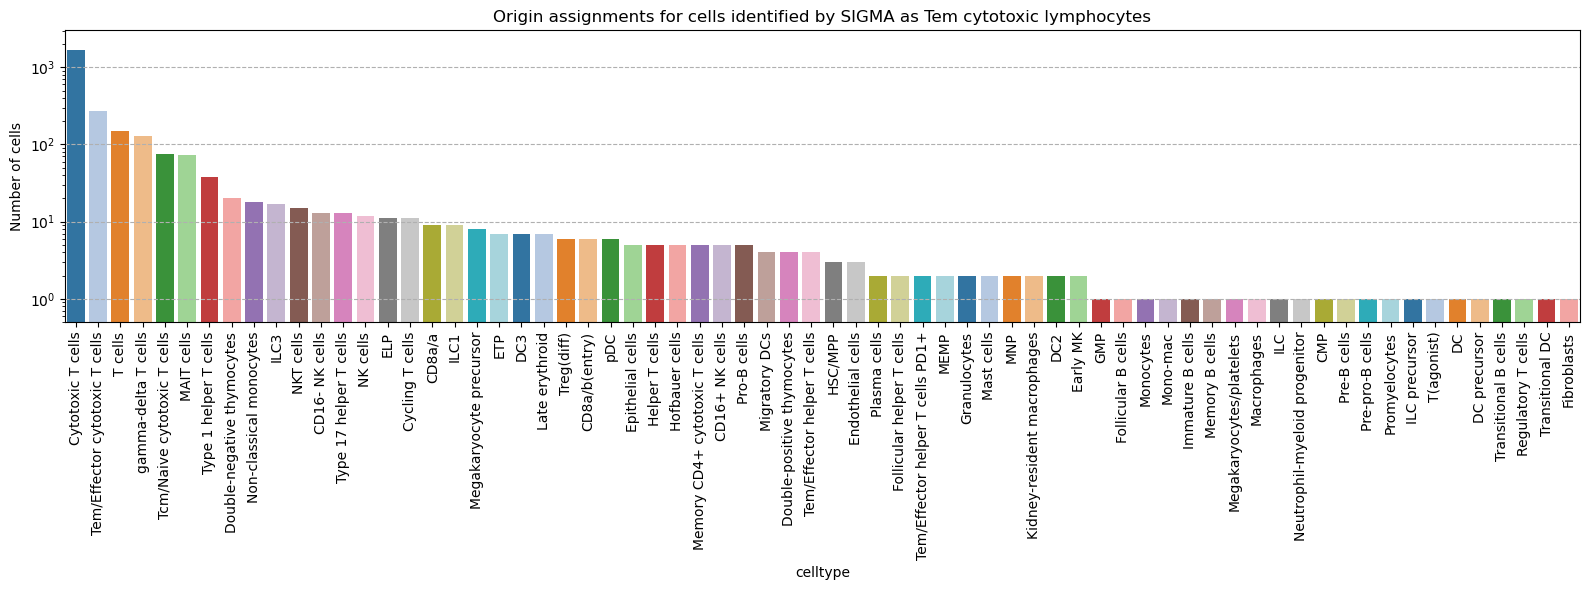

In [6]:
import seaborn as sns

celltype_counts = (
    sub_adata_sumry.obs['celltype']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'celltype'})
    .sort_values('count', ascending=False)
)

celltype_counts['celltype'] = celltype_counts['celltype'].astype(str)

plt.figure(figsize=(16, 6))
ax = sns.barplot(
    data=celltype_counts,
    x='celltype',
    y='count',
    hue='celltype',
    palette='tab20',
    dodge=False,
    order=celltype_counts['celltype']
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.ylabel('Number of cells')
plt.grid(axis='y', linestyle='--')
plt.yscale('log')
plt.ylim(0.5, celltype_counts['count'].max()*1.8)
plt.title("Origin assignments for cells identified by SIGMA as Tem cytotoxic lymphocytes")

# # Ajouter les chiffres au-dessus des barres
# for p in ax.patches:
#     height = p.get_height()
#     if np.isfinite(height):
#         label = f'{int(height):,}'.replace(',', ' ')
#         ax.text(
#             p.get_x() + p.get_width() / 2.,
#             height * 1.05 if height > 0 else 0.5,
#             label,
#             ha='center',
#             va='bottom',
#             fontsize=9
#         )

# Extract colors from the current plot and store in color_mapping
color_mapping = {}
for patch, celltype in zip(ax.patches, celltype_counts['celltype']):
    color_mapping[celltype] = patch.get_facecolor()

plt.tight_layout()
plt.savefig("figures/dominguez_CelltypeDistribution.svg", dpi=500)
plt.show()

/home/lemgui01/.miniconda3/envs/SIGMA/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


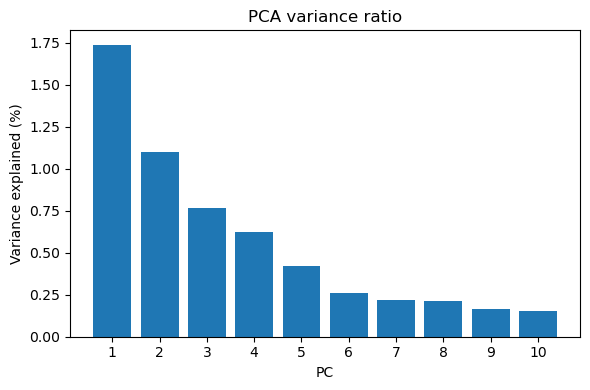

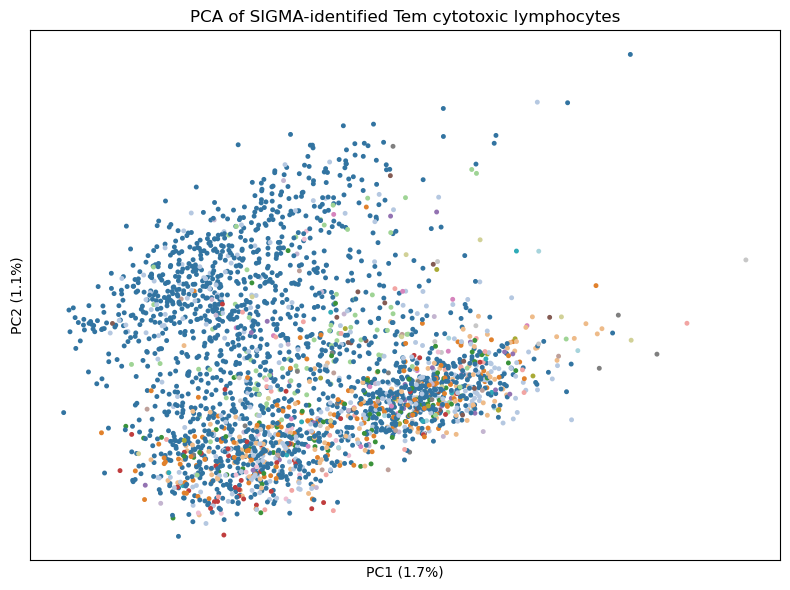

In [7]:
# PCA plot
sc.pp.pca(sub_adata_sumry, n_comps=10)
pc_var = sub_adata_sumry.uns["pca"]["variance_ratio"][:10]
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(pc_var) + 1), pc_var * 100)
plt.xticks(range(1, 11))
plt.xlabel("PC")
plt.ylabel("Variance explained (%)")
plt.title("PCA variance ratio")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))

pc_var = sub_adata_sumry.uns['pca']['variance_ratio']
sc.pl.pca(
    sub_adata_sumry,
    s=50,
    color='celltype',
    palette=color_mapping,
    legend_loc='none',
    show=False,
    ax=ax2
)

ax2.set_xlabel(f'PC1 ({pc_var[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pc_var[1]*100:.1f}%)')
ax2.set_title('PCA of SIGMA-identified Tem cytotoxic lymphocytes')

plt.tight_layout()
plt.savefig("figures/dominguez_PCA.tiff", dpi=500, bbox_inches="tight")
plt.show()

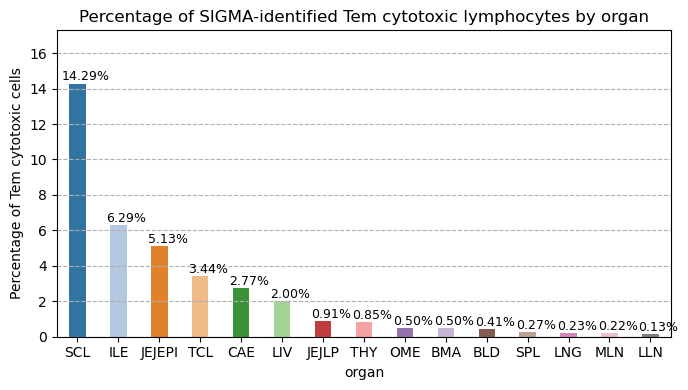

In [8]:
# Plot proportion of Tem cells per organ
organ_counts = (
    sub_adata_sumry.obs['organ']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'organ'})
    .sort_values('count', ascending=False)
)

for org in organ_counts['organ']:
    ncells_in_org = adata_sumry.obs['organ'].value_counts().get(org, 0)
    organ_counts.loc[organ_counts['organ'] == org, 'proportion'] = (
        organ_counts.loc[organ_counts['organ'] == org, 'count'].values[0] / ncells_in_org*100
        if ncells_in_org > 0 else 0.0
    )

# sort by proportion descending
organ_counts = organ_counts.sort_values('proportion', ascending=False).reset_index(drop=True)
organ_counts['organ'] = organ_counts['organ'].astype(str)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=organ_counts,
    x='organ',
    y='proportion',
    hue='organ',
    palette='tab20',
    dodge=False,
    width=0.4,
    order=organ_counts['organ'].tolist()
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_ylabel('Percentage of Tem cytotoxic cells')
ax.set_ylim(0, organ_counts['proportion'].max()+3 if organ_counts['proportion'].max() > 0 else 1)
plt.grid(axis='y', linestyle='--')
plt.title("Percentage of SIGMA-identified Tem cytotoxic lymphocytes by organ")

# Add percentage labels above bars
for p in ax.patches:
    height = p.get_height()
    if np.isfinite(height):
        label = f'{height:.2f}%'
        ax.text(
            p.get_x() + p.get_width(),
            height + 0.001 if height > 0 else 0.01,
            label,
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig("figures/dominguez_OrganDistribution.svg", dpi=500, bbox_inches="tight")
plt.show()

# Why all TEM cyto were not found ?

In [9]:
tem_author = adata_sumry[adata_sumry.obs["celltype"] == "Tem/Effector cytotoxic T cells"]

print(f"% among TEM from authors : {np.sum(tem_found_by_sigma)/tem_author.n_obs:.3%}")

tem_df = tem_author.to_df()
tem_df["identified"] = tem_author.obs["Identified by SIGMA"].values

tem_df_melt = tem_df.melt(
    id_vars="identified",
    var_name="gene",
    value_name="expression"
)

% among TEM from authors : 27.675%


/tmp/ipykernel_2123873/3025374135.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
/tmp/ipykernel_2123873/3025374135.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)
/tmp/ipykernel_2123873/3025374135.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
/tmp/ipykernel_2123873/3025374135.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)


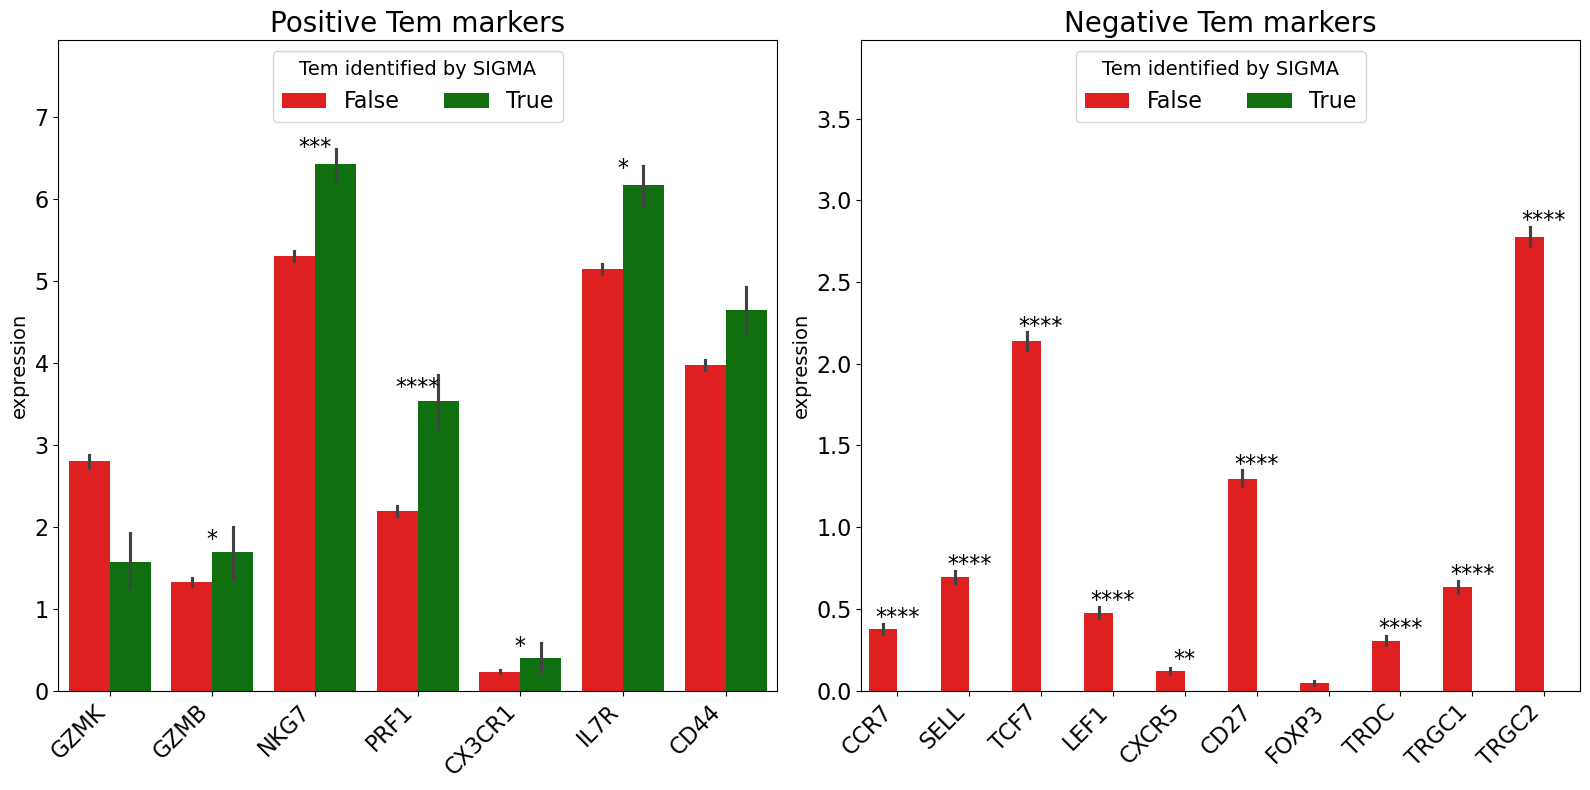

In [10]:
positive_mark = ["GZMK", "GZMB", "NKG7", "PRF1", "CX3CR1", "IL7R", "CD44"]
negative_mark = ["CCR7", "SELL", "TCF7", "LEF1", "CXCR5", "CD27", "FOXP3", "TRDC", "TRGC1", "TRGC2"]

fig, ax = plt.subplots(1,2,figsize=(16, 8))
ax = ax.flatten()
cpt = 0

for gene_chosen in {"Positive Tem markers":positive_mark, "Negative Tem markers":negative_mark}.items():

    df = tem_df_melt.loc[tem_df_melt["gene"].isin(gene_chosen[1]), ["gene", "identified", "expression"]].copy()
    df = df.dropna(subset=["expression"]).copy()
    df["identified"] = df["identified"].eq("True")

    mannwhit_res = {}
    for gene, sub in df.groupby("gene", sort=False):
        no_ident = sub.loc[~sub["identified"], "expression"].to_numpy()
        ident = sub.loc[sub["identified"],  "expression"].to_numpy()
        U, p = mannwhitneyu(no_ident, ident, alternative="less" if gene_chosen[0] == "Positive Tem markers" else "greater")
        mannwhit_res[gene] = (U, p)

    mannwhit_df = (
        pd.DataFrame.from_dict(mannwhit_res, orient="index", columns=["U_stat", "p_value"])
        .rename_axis("gene").reset_index()
        )
    mannwhit_df["p_value_adj"] = multipletests(mannwhit_df["p_value"], method="fdr_bh")[1]

    plot_df = df.assign(identified=df["identified"].map({False: "False", True: "True"}))

    sns.barplot(data=plot_df,
        x="gene", y="expression", hue="identified",
        order=gene_chosen[1], ax=ax[cpt], 
        palette={"False": "red", "True": "green"}, 
    )

    bar_top = plot_df.groupby(["gene", "identified"])["expression"].mean().groupby("gene").max()

    for i, gene in enumerate(gene_chosen[1]):
        pval = mannwhit_df.loc[mannwhit_df["gene"] == gene,"p_value_adj"].values

        y0 = float(bar_top.loc[gene])
        pad = 0.01 * y0

        ax[cpt].text(
            i, y0 + pad,
            p_to_star(pval),
            ha="center", va="bottom", fontsize=16
        )

    ax[cpt].set_ylim(0, ax[cpt].get_ylim()[1]+1)
    ax[cpt].set_xlabel(None)
    ax[cpt].yaxis.label.set_size(14)
    ax[cpt].set_title(f"{gene_chosen[0]}", fontsize=20)
    ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
    ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)
    ax[cpt].legend(title="Tem identified by SIGMA",
                   loc="upper center", ncol=2, fontsize=16, title_fontsize=14)
    cpt += 1

plt.tight_layout()
fig.savefig("figures/dominguez_Markers.svg", bbox_inches="tight", dpi=500)
plt.show()

In [13]:
t_author = adata_sumry[adata_sumry.obs["celltype"] == "Cytotoxic T cells"]

t_df = t_author.to_df()
t_df["identified"] = t_author.obs["Identified by SIGMA"].values

t_df_melt = t_df.melt(
    id_vars="identified",
    var_name="gene",
    value_name="expression"
)

/tmp/ipykernel_2068849/2106956510.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
/tmp/ipykernel_2068849/2106956510.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)
/tmp/ipykernel_2068849/2106956510.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
/tmp/ipykernel_2068849/2106956510.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)


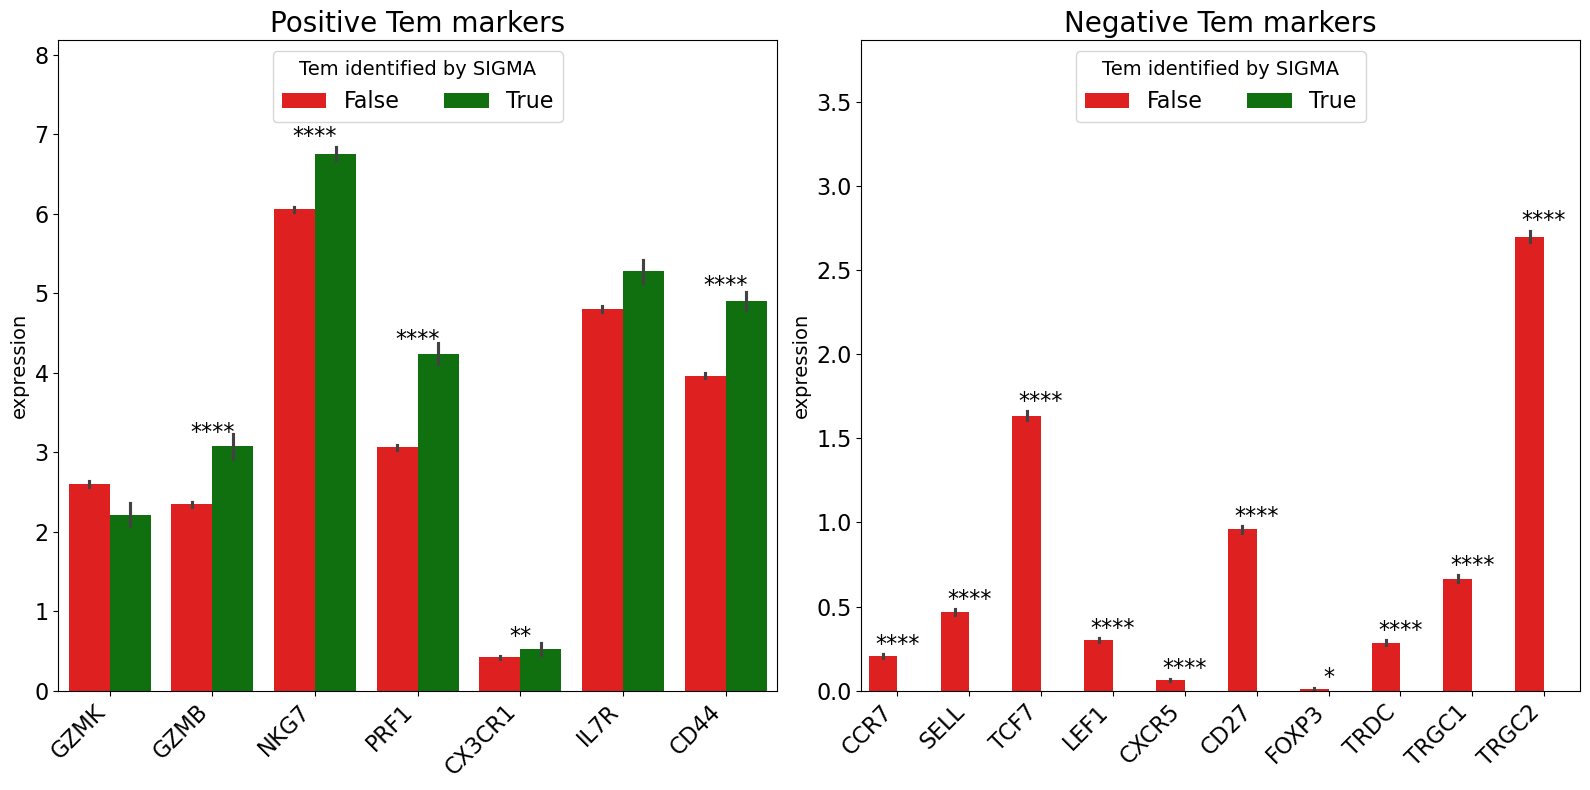

In [14]:
positive_mark = ["GZMK", "GZMB", "NKG7", "PRF1", "CX3CR1", "IL7R", "CD44"]
negative_mark = ["CCR7", "SELL", "TCF7", "LEF1", "CXCR5", "CD27", "FOXP3", "TRDC", "TRGC1", "TRGC2"]

fig, ax = plt.subplots(1,2,figsize=(16, 8))
ax = ax.flatten()
cpt = 0

for gene_chosen in {"Positive Tem markers":positive_mark, "Negative Tem markers":negative_mark}.items():

    df = t_df_melt.loc[t_df_melt["gene"].isin(gene_chosen[1]), ["gene", "identified", "expression"]].copy()
    df = df.dropna(subset=["expression"]).copy()
    df["identified"] = df["identified"].eq("True")

    mannwhit_res = {}
    for gene, sub in df.groupby("gene", sort=False):
        no_ident = sub.loc[~sub["identified"], "expression"].to_numpy()
        ident = sub.loc[sub["identified"],  "expression"].to_numpy()
        U, p = mannwhitneyu(no_ident, ident, alternative="less" if gene_chosen[0] == "Positive Tem markers" else "greater")
        mannwhit_res[gene] = (U, p)

    mannwhit_df = (
        pd.DataFrame.from_dict(mannwhit_res, orient="index", columns=["U_stat", "p_value"])
        .rename_axis("gene").reset_index()
        )
    mannwhit_df["p_value_adj"] = multipletests(mannwhit_df["p_value"], method="fdr_bh")[1]

    plot_df = df.assign(identified=df["identified"].map({False: "False", True: "True"}))

    sns.barplot(data=plot_df,
        x="gene", y="expression", hue="identified",
        order=gene_chosen[1], ax=ax[cpt], 
        palette={"False": "red", "True": "green"}, 
    )

    bar_top = plot_df.groupby(["gene", "identified"])["expression"].mean().groupby("gene").max()

    for i, gene in enumerate(gene_chosen[1]):
        pval = mannwhit_df.loc[mannwhit_df["gene"] == gene,"p_value_adj"].values

        y0 = float(bar_top.loc[gene])
        pad = 0.01 * y0

        ax[cpt].text(
            i, y0 + pad,
            p_to_star(pval),
            ha="center", va="bottom", fontsize=16
        )

    ax[cpt].set_ylim(0, ax[cpt].get_ylim()[1]+1)
    ax[cpt].set_xlabel(None)
    ax[cpt].yaxis.label.set_size(14)
    ax[cpt].set_title(f"{gene_chosen[0]}", fontsize=20)
    ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
    ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)
    ax[cpt].legend(title="Tem identified by SIGMA",
                   loc="upper center", ncol=2, fontsize=16, title_fontsize=14)
    cpt += 1

plt.tight_layout()
# fig.savefig("figures/dominguez_Markers.svg", bbox_inches="tight", dpi=500)
plt.show()